# Compare savegames — markets & goods

Loads format-2 `.pkl` files (`locations`, `market_goods`, `market_food`, `countries`). Works with **one snapshot** or many (same layout as `compare_savegames.ipynb`).

**Abstract food market:** `market_food` is one row per trade market (engine fields: `food` stockpile, `food_max`, `price`, `food_consumption`, etc.), separate from trade-good rows in `market_goods`.

**Single save:** use e.g. `first_savegame = 0` and `last_savegame = 1` so only the first `.pkl` in the folder is loaded (or point `PKL_PATH` at a folder that contains only one file).

In [57]:
"""Load .pkl snapshots; extract market_goods, market_food (+ optional locations merge)."""
import pandas as pd
from IPython.display import display

from analysis.savegame import resolve_pkl_dir, locations_df_from_pkl

# None = auto (newest playthrough), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0   # slice start (0 = first file)
last_savegame = None  # None = all; set to 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

# Format 2: dict with "market_goods"; legacy single-DF not supported here
market_by_label = {}
market_food_by_label = {}
locations_by_label = {}
countries_by_label = {}
for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    mg = payload["market_goods"]
    market_by_label[label] = mg.copy() if isinstance(mg, pd.DataFrame) else pd.DataFrame()
    market_by_label[label]["snapshot"] = label
    mf = payload.get("market_food")
    market_food_by_label[label] = mf.copy() if isinstance(mf, pd.DataFrame) else pd.DataFrame()
    market_food_by_label[label]["snapshot"] = label
    locations_by_label[label] = locations_df_from_pkl(payload)
    cg = payload.get("countries")
    countries_by_label[label] = cg.copy() if isinstance(cg, pd.DataFrame) else pd.DataFrame()

n_snap = len(market_by_label)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(market_by_label.keys())}")

Loaded 100 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\c2ea16f6_f1f4_4102_9989_09477a60d3af
Labels: ['20260401_181056', '20260401_181218', '20260401_181351', '20260401_181524', '20260401_181651', '20260401_181822', '20260401_181948', '20260401_182115', '20260401_182242', '20260401_182407', '20260401_182529', '20260401_182649', '20260401_182812', '20260401_182944', '20260401_183108', '20260401_183231', '20260401_183355', '20260401_183512', '20260401_183633', '20260401_183752', '20260401_183912', '20260401_184028', '20260401_184152', '20260401_184315', '20260401_184438', '20260401_184649', '20260401_190624', '20260401_190736', '20260401_190848', '20260401_191002', '20260401_191115', '20260401_191229', '20260401_191342', '20260401_191457', '20260401_191611', '20260401_191726', '20260401_191842', '20260401_191958', '20260401_192113', '20260401_192228', '20260401_192345', '20260401_192501', '20260401_192616', '20260401_192728', '20260401_192

In [58]:
# Single combined table (one or many snapshots)
market_all = pd.concat(market_by_label.values(), ignore_index=True) if market_by_label else pd.DataFrame()

if market_all.empty:
    print("No market_goods rows.")
else:
    print(f"Total rows (all markets × goods × snapshots): {len(market_all)}")
    print(f"Columns ({len(market_all.columns)}):", list(market_all.columns)[:25], "..." if len(market_all.columns) > 25 else "")

Total rows (all markets × goods × snapshots): 1183950
Columns (43): ['market_id', 'market_center_slug', 'good_id', 'price', 'supplied_Production', 'demanded_Pops', 'demanded_BurgherTrades', 'demanded_Building', 'taken_Pops', 'taken_BurgherTrades', 'taken_Building', 'impact', 'supply', 'demand', 'total_taken', 'last_month', 'possible', 'allowed_export_amount', 'stockpile', 'locations_with_this_as_raw_material', 'priority', 'history', 'demanded_Roads', 'taken_Roads', 'surplus'] ...


In [59]:
# Abstract food market (engine): one row per trade market per snapshot — not the same as trade-good rows
market_food_all = (
    pd.concat(market_food_by_label.values(), ignore_index=True) if market_food_by_label else pd.DataFrame()
)

if market_food_all.empty:
    print(
        "No market_food rows. Re-run the savegame watcher / processor with current ProsperPerishCalcs "
        "so pkls include market_food, or load a newer playthrough folder."
    )
else:
    pref = [
        "snapshot",
        "market_id",
        "market_center_slug",
        "food",
        "food_max",
        "price",
        "food_consumption",
        "food_supply",
        "food_not_traded",
        "missing",
        "population",
        "capacity",
    ]
    show_cols = [c for c in pref if c in market_food_all.columns]
    print(f"market_food rows: {len(market_food_all)}, total columns: {len(market_food_all.columns)}")
    display(
        market_food_all[show_cols]
        .sort_values(["snapshot", "market_center_slug"], na_position="last")
        .head(40)
    )

market_food rows: 15786, total columns: 840


,snapshot,market_id,market_center_slug,food,food_max,price,food_consumption,food_supply,food_not_traded,missing,population,capacity
56,20260401_181056,56,adan,17908.28611,18703.51406,0.10653,-3632.57901,535.24223,535.24223,492.79874,3018.20940,7.70175
86,20260401_181056,86,akita,14693.88342,14693.88342,0.09933,-3019.99872,1102.52194,1102.52194,NaN,2160.82431,25.14500
58,20260401_181056,58,al_ahsa,4058.89313,4115.24777,0.08491,-619.89615,115.08061,115.08061,NaN,458.43195,2.06612
59,20260401_181056,59,al_hajr,6265.54450,6265.54450,0.06823,-714.48466,461.73212,461.73212,NaN,882.32282,2.18712
33,20260401_181056,33,alexandria,49362.07021,49362.07021,0.06023,-4430.00868,825.00303,825.00328,195.33908,5164.77767,14.23930
39,20260401_181056,39,algiers,4144.82621,8265.74636,0.12916,-562.40760,193.61302,193.61302,23.67416,1455.07614,2.97218
61,20260401_181056,61,almaty,12108.04144,12108.04144,0.03097,-476.49757,1024.75203,1024.75203,NaN,524.31453,4.89299
116,20260401_181056,116,angkor,35822.97397,40834.71101,0.06181,-4092.60353,-907.94409,-907.94409,1003.50704,3375.40129,15.58754
19,20260401_181056,19,astrakhan,3495.34099,3495.34099,0.04034,-204.18996,362.16635,362.16635,NaN,227.11664,3.73968
45,20260401_181056,45,axum,28154.90124,28154.90124,0.04138,-1229.11624,1414.82454,1414.82454,59.55919,1920.32378,7.83919


In [60]:
# Per-snapshot summary (works with n_snap == 1)
rows = []
for label, mg in market_by_label.items():
    if mg.empty:
        rows.append({"snapshot": label, "markets": 0, "goods_rows": 0, "unique_goods": 0})
        continue
    rows.append(
        {
            "snapshot": label,
            "markets": mg["market_id"].nunique() if "market_id" in mg.columns else 0,
            "goods_rows": len(mg),
            "unique_goods": mg["good_id"].nunique() if "good_id" in mg.columns else 0,
        }
    )
summary = pd.DataFrame(rows)

In [61]:
# Optional: attach location-level market_name (trade center slug) for context
# For each snapshot, one row per location with market_name + market_id
loc_parts = []
for label, loc in locations_by_label.items():
    if loc is None or loc.empty:
        continue
    use = loc[[c for c in ("slug", "market_name", "market", "owner_name", "country_tag") if c in loc.columns]].copy()
    use["snapshot"] = label
    loc_parts.append(use)
locations_all = pd.concat(loc_parts, ignore_index=True) if loc_parts else pd.DataFrame()

if not locations_all.empty:
    print("Locations sample (market + owner) — table omitted")
else:
    print("No locations data in payload.")

Locations sample (market + owner) — table omitted


In [62]:
# Numeric spot-check: mean price per good (if column exists), per snapshot
if not market_all.empty and "price" in market_all.columns and "good_id" in market_all.columns:
    g = (
        market_all.groupby(["snapshot", "good_id"], as_index=False)["price"]
        .mean()
        .sort_values(["snapshot", "price"], ascending=[True, False])
    )
    print("Mean price by snapshot × good_id (top 15 rows)")
else:
    print("Skip: need non-empty market_goods with 'price' and 'good_id'.")

Mean price by snapshot × good_id (top 15 rows)


In [63]:
# Wide comparison for one good across markets (snapshot columns if 2+ snapshots)
GOOD_ID = "victuals"  # change to any good_id present in your save

if n_snap >= 1 and not market_all.empty and "good_id" in market_all.columns:
    sub = market_all[market_all["good_id"] == GOOD_ID].copy()
    if sub.empty:
        print(f"No rows for good_id={GOOD_ID!r}. Try: {market_all['good_id'].drop_duplicates().head(20).tolist()}")
    else:
        cols = [c for c in ("price", "supply", "demand") if c in sub.columns]
        if cols:
            wide = sub.pivot_table(index="market_center_slug", columns="snapshot", values=cols[0], aggfunc="mean")
            print(f"{cols[0]} for {GOOD_ID!r} (markets × snapshots)")
        else:
            pass
else:
    print("Need market_goods data.")

price for 'victuals' (markets × snapshots)


## Global trade good: demand, supply, price over time

Set **`GOOD_ID`** below to a game good key (e.g. `grain`, `iron`, `clay`).

- **Global supply / demand**: sum of `supply` and `demand` across all markets in each snapshot.
- **Average price**: mean of `price` across markets (unweighted), per snapshot.

With **one** snapshot you get a single table row. With **many** snapshots, the table is ordered in time and line charts show the series.

Using good_id='victuals' (15786 market rows across snapshots)
Global aggregates per snapshot (mean price, summed supply/demand)


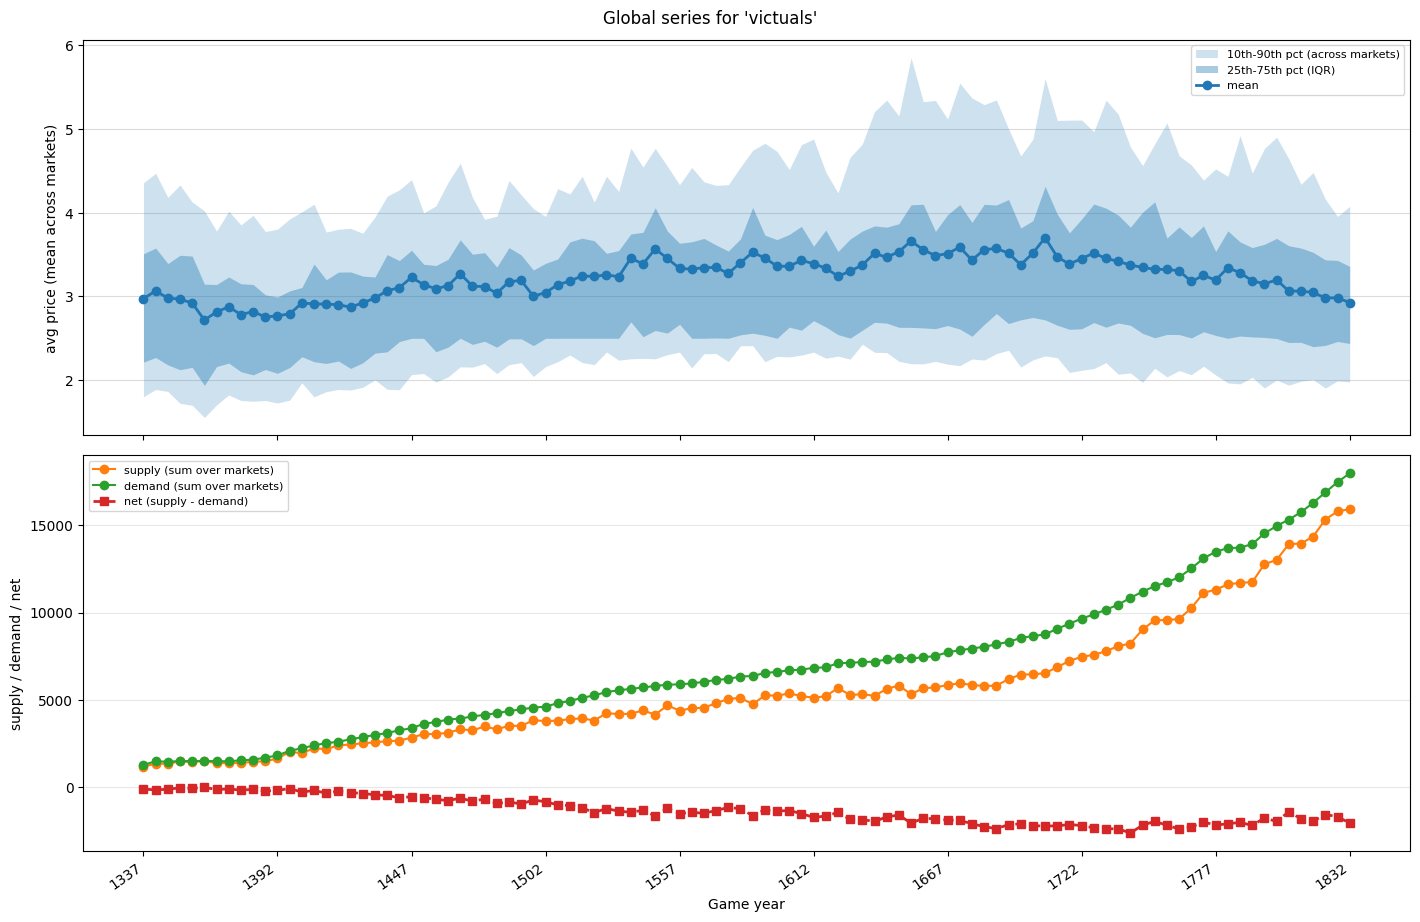

In [64]:


import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator


def _rows_for_good(df: pd.DataFrame, q: str) -> tuple[pd.DataFrame, str | None]:
    if df.empty or "good_id" not in df.columns:
        return pd.DataFrame(), None
    q = str(q).strip()
    m = df["good_id"].astype(str).str.lower() == q.lower()
    sub = df.loc[m].copy()
    if sub.empty:
        return pd.DataFrame(), None
    return sub, str(sub["good_id"].iloc[0])


sub, resolved = _rows_for_good(market_all, GOOD_ID)
if sub.empty:
    sample = sorted(market_all["good_id"].dropna().unique().tolist())[:40]
    print(f"No rows for good matching {GOOD_ID!r}. Sample good_id values: {sample}")
else:
    print(f"Using good_id={resolved!r} ({len(sub)} market rows across snapshots)")
    agg_parts = {}
    if "price" in sub.columns:
        agg_parts["avg_price"] = ("price", "mean")
    if "supply" in sub.columns:
        agg_parts["global_supply"] = ("supply", "sum")
    if "demand" in sub.columns:
        agg_parts["global_demand"] = ("demand", "sum")
    agg_parts["n_markets"] = ("market_id", "nunique")

    global_good = sub.groupby("snapshot", as_index=False).agg(**agg_parts)
    global_good = global_good.sort_values("snapshot").reset_index(drop=True)
    if "global_supply" in global_good.columns and "global_demand" in global_good.columns:
        global_good["net_supply_minus_demand"] = (
            global_good["global_supply"] - global_good["global_demand"]
        )

    print("Global aggregates per snapshot (mean price, summed supply/demand)")

    # Per-snapshot price spread across markets (ribbons on avg_price panel)
    price_band = None
    if "price" in sub.columns:
        _snaps = global_good["snapshot"].tolist()
        price_band = (
            sub.groupby("snapshot")["price"]
            .agg(
                p10=lambda s: s.quantile(0.1),
                p25=lambda s: s.quantile(0.25),
                p75=lambda s: s.quantile(0.75),
                p90=lambda s: s.quantile(0.9),
            )
            .reindex(_snaps)
        )

    # Line charts: price panel; supply+demand+net on one panel when both exist
    panels: list[str] = []
    if "avg_price" in global_good.columns:
        panels.append("price")
    if "global_supply" in global_good.columns and "global_demand" in global_good.columns:
        panels.append("supply_demand_net")
    else:
        if "global_supply" in global_good.columns:
            panels.append("supply")
        if "global_demand" in global_good.columns:
            panels.append("demand")

    if not panels:
        print("No plottable columns (need price and/or supply/demand).")
    else:
        n = len(panels)
        fig, axes = plt.subplots(n, 1, figsize=(13 * 1.1, 3.12 * 1.5 * n), sharex=True)
        if n == 1:
            axes = [axes]
        x = np.arange(len(global_good))
        for ax, panel in zip(axes, panels):
            if panel == "price":
                color = "C0"
                if price_band is not None:
                    ax.fill_between(
                        x,
                        price_band["p10"],
                        price_band["p90"],
                        alpha=0.22,
                        color=color,
                        linewidth=0,
                        label="10th-90th pct (across markets)",
                    )
                    ax.fill_between(
                        x,
                        price_band["p25"],
                        price_band["p75"],
                        alpha=0.38,
                        color=color,
                        linewidth=0,
                        label="25th-75th pct (IQR)",
                    )
                    ax.plot(
                        x,
                        global_good["avg_price"],
                        marker="o",
                        color=color,
                        linewidth=2,
                        zorder=3,
                        label="mean",
                    )
                    ax.legend(loc="best", fontsize=8)
                else:
                    ax.plot(x, global_good["avg_price"], marker="o", color=color)
                ax.set_ylabel("avg price (mean across markets)")
                ax.set_axisbelow(True)
                ax.yaxis.set_major_locator(MultipleLocator(1))
                ax.grid(True, axis="y", which="major", alpha=0.45, linestyle="-", linewidth=0.8, zorder=0)
            elif panel == "supply_demand_net":
                ax.plot(
                    x,
                    global_good["global_supply"],
                    marker="o",
                    color="C1",
                    label="supply (sum over markets)",
                )
                ax.plot(
                    x,
                    global_good["global_demand"],
                    marker="o",
                    color="C2",
                    label="demand (sum over markets)",
                )
                ax.plot(
                    x,
                    global_good["net_supply_minus_demand"],
                    marker="s",
                    color="C3",
                    linestyle="--",
                    linewidth=2,
                    label="net (supply - demand)",
                )
                ax.legend(loc="best", fontsize=8)
                ax.set_ylabel("supply / demand / net")
                ax.grid(True, axis="y", alpha=0.3)
            elif panel == "supply":
                ax.plot(x, global_good["global_supply"], marker="o", color="C1")
                ax.set_ylabel("global supply (sum)")
                ax.grid(True, axis="y", alpha=0.3)
            elif panel == "demand":
                ax.plot(x, global_good["global_demand"], marker="o", color="C2")
                ax.set_ylabel("global demand (sum)")
                ax.grid(True, axis="y", alpha=0.3)
        # Same time axis as compare_savegames.ipynb: first snapshot = start_year, +5y per pkl
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_game_ticks = 10  # match compare_savegames (~one label every ~50y when many pkls)
        n_pts = len(x)
        if n_pts <= 1:
            tick_positions = list(range(n_pts))
        elif n_pts <= n_game_ticks:
            tick_positions = list(range(n_pts))
        else:
            step = (n_pts - 1) / (n_game_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_game_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
        axes[-1].set_xticks(tick_positions)
        axes[-1].set_xticklabels(tick_labels, rotation=35, ha="right")
        axes[-1].set_xlabel("Game year")
        fig.suptitle(f"Global series for {resolved!r}")
        plt.tight_layout()
        plt.show()

### All goods: net global imbalance (%, 25-year buckets)

Each cell is **100 × net / (Σsupply + Σdemand)** for that good × **25-year bucket** across all markets. **Supply and demand are summed** over consecutive snapshots that cover **25 game years** (default: **5** snapshots × **5** years each); then **net = Σsupply − Σdemand** on that combined flow (empty when there is no flow).

**Colors** use **one scale for the whole table**, fixed to **−50 … +50** on the net % (so the midrange isn’t washed out); values **outside** that range still appear in the cells, but read as saturated at the same red/green.

Columns are **`start_year + 0, 25, 50, …`** (bucket starts). Tune **`bucket_years`** and **`years_per_snapshot`** in the next cell if your cadence differs.

In [65]:
import numpy as np
from IPython.display import display

# Timeline: first snapshot = start_year, +years_per_snapshot game years per pkl.
# Buckets: sum supply/demand over snapshots_per_bucket snapshots, then net % on that combined flow.
start_year = 1337  # EU5 start (same as compare_savegames)
years_per_snapshot = 5
bucket_years = 25
snapshots_per_bucket = max(1, bucket_years // years_per_snapshot)
# Color scale for heatmap (symmetric); values still shown numerically beyond this range
heatmap_vmax = 50

if market_all.empty or not {"good_id", "supply", "demand"}.issubset(market_all.columns):
    print("Need market_all with good_id, supply, demand.")
else:
    agg = market_all.groupby(["good_id", "snapshot"], as_index=False).agg(
        global_supply=("supply", "sum"),
        global_demand=("demand", "sum"),
    )
    snap_order = sorted(agg["snapshot"].unique(), key=lambda x: str(x))
    snap_to_idx = {s: i for i, s in enumerate(snap_order)}
    agg["snap_idx"] = agg["snapshot"].map(snap_to_idx)
    agg["bucket"] = agg["snap_idx"] // snapshots_per_bucket

    bucketed = agg.groupby(["good_id", "bucket"], as_index=False).agg(
        global_supply=("global_supply", "sum"),
        global_demand=("global_demand", "sum"),
    )
    bucketed["net"] = bucketed["global_supply"] - bucketed["global_demand"]
    denom = bucketed["global_supply"] + bucketed["global_demand"]
    bucketed["net_pct_flow"] = np.where(denom > 0, 100.0 * bucketed["net"] / denom, np.nan)
    bucketed["flow"] = bucketed["global_supply"].abs() + bucketed["global_demand"].abs()

    flow_stats = (
        bucketed.groupby("good_id")["flow"]
        .agg(mean_abs_flow="mean", total_flow="sum")
        .sort_values("mean_abs_flow", ascending=False)
    )
    n_with_flow = int((flow_stats["total_flow"] > 0).sum())
    print(
        f"Goods with market flow (|S|+|D| > 0 in any bucket): {n_with_flow} / {len(flow_stats)}; "
        "heatmap rows: mean per-bucket |S|+|D|, high to low"
    )

    net_wide = bucketed.pivot(index="good_id", columns="bucket", values="net_pct_flow")
    net_wide = net_wide.reindex(flow_stats.index)
    net_wide = net_wide.reindex(sorted(net_wide.columns), axis=1)
    net_wide.columns = [str(start_year + int(b) * bucket_years) for b in net_wide.columns]

    styled = (
        net_wide.style.format("{:.1f}", na_rep="")
        .background_gradient(
            cmap="RdYlGn", axis=None, vmin=-heatmap_vmax, vmax=heatmap_vmax
        )
        .set_caption(
            f"{bucket_years}y buckets: 100×net/(S+D); colors [-{heatmap_vmax}, +{heatmap_vmax}] (same scale all cells); numbers uncapped; rows by mean |S|+|D|"
        )
    )
    display(styled)

Goods with market flow (|S|+|D| > 0 in any bucket): 75 / 75; heatmap rows: mean per-bucket |S|+|D|, high to low


,1337,1362,1387,1412,1437,1462,1487,1512,1537,1562,1587,1612,1637,1662,1687,1712,1737,1762,1787,1812
good_id,,,,,,,,,,,,,,,,,,,,
victuals,-3.1,-3.3,-4.6,-6.2,-9.1,-10.2,-10.5,-13.4,-13.9,-12.1,-12.0,-13.7,-14.0,-14.5,-14.9,-13.2,-11.2,-9.2,-6.9,-5.6
lumber,17.3,20.9,15.4,12.1,7.7,7.7,7.3,5.9,5.8,6.7,7.0,7.0,9.4,9.0,9.5,9.8,12.2,12.5,13.5,12.3
livestock,45.0,50.8,48.6,44.3,40.1,33.6,35.5,34.2,32.0,31.0,29.9,27.7,25.1,22.8,20.9,21.5,18.9,19.2,19.7,18.5
fruit,-11.7,3.9,5.0,7.7,7.5,3.1,8.0,4.4,4.6,4.3,4.2,1.3,-1.5,-1.2,-2.1,5.2,3.8,5.4,10.1,8.3
wheat,33.7,36.3,31.3,30.1,22.7,15.1,22.4,20.0,18.1,21.7,18.9,17.4,10.1,12.0,9.9,15.4,14.7,13.5,16.8,14.4
millet,-5.3,4.1,8.1,9.1,13.2,12.7,17.7,17.6,11.8,16.1,12.9,12.7,3.7,9.2,4.4,11.4,11.6,10.8,18.9,16.9
fish,14.2,25.4,24.3,21.9,19.6,14.8,15.7,14.4,13.3,12.7,13.2,12.1,10.0,7.7,7.3,10.1,10.5,12.7,17.1,18.1
rice,15.7,25.6,24.1,25.9,18.8,13.6,23.9,23.9,15.4,16.8,17.3,21.1,14.2,16.7,12.0,14.8,18.1,15.5,22.7,17.2
legumes,12.0,22.5,21.2,24.0,18.0,14.2,17.9,16.5,13.8,13.9,13.5,13.5,11.9,11.7,9.5,14.7,14.1,16.1,24.9,21.9


### Nominal market flow per good (GDP-analog, not literal GDP)

For each market row we use **cleared-flow proxy** `min(supply, demand)` (short side), times **local** `price`, then **sum over all markets** for each `good_id` and `snapshot`.

That gives **Σ min(S,D)×P** in game price units — a useful scalar for comparing how “large” each good is in nominal terms over time. It is **not** national-accounts GDP (no value added; summing regional markets can overlap conceptually with trade links).

If the save has `total_taken`, we also show **Σ total_taken×P** as an alternative tied to realized takes.

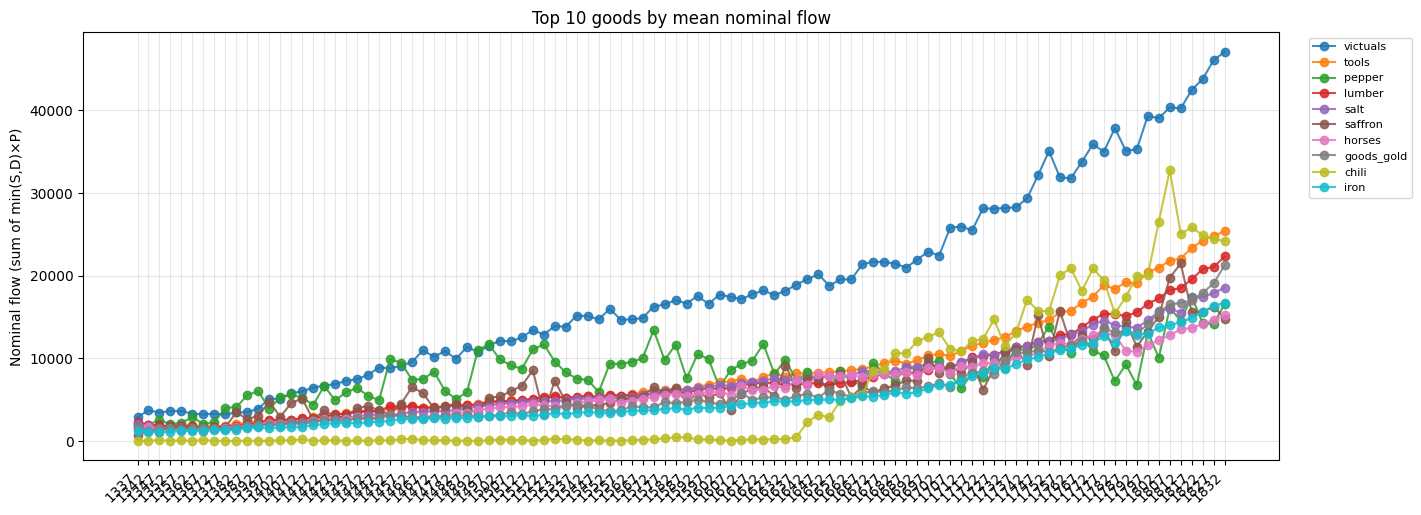

In [66]:
import numpy as np
import matplotlib.pyplot as plt

REQUIRED = {"good_id", "supply", "demand", "price", "snapshot"}
TOP_N_GOODS = 10

if market_all.empty or not REQUIRED.issubset(market_all.columns):
    print("Need market_all with columns:", sorted(REQUIRED))
else:
    df = market_all.copy()
    s = df["supply"].fillna(0).clip(lower=0)
    d = df["demand"].fillna(0).clip(lower=0)
    cleared = np.minimum(s, d)
    df["nominal_min_sd"] = cleared * df["price"].fillna(0)

    flow = df.groupby(["good_id", "snapshot"], as_index=False).agg(
        nominal_flow_min_sd=("nominal_min_sd", "sum"),
    )
    flow = flow.sort_values(["good_id", "snapshot"]).reset_index(drop=True)

    snap_order = sorted(flow["snapshot"].unique(), key=lambda x: str(x))
    mean_by_good = flow.groupby("good_id")["nominal_flow_min_sd"].mean().sort_values(ascending=False)
    top_goods = mean_by_good.head(TOP_N_GOODS).index.tolist()
    sub = flow[flow["good_id"].isin(top_goods)].pivot(
        index="snapshot", columns="good_id", values="nominal_flow_min_sd"
    )
    sub = sub.reindex(snap_order).fillna(0.0)

    x = np.arange(len(snap_order))
    x_labels = [str(start_year + i * years_per_snapshot) for i in range(len(snap_order))]

    fig, ax = plt.subplots(figsize=(13 * 1.1, 3.5 * 1.5))
    for g in top_goods:
        if g in sub.columns:
            ax.plot(x, sub[g].values, marker="o", label=g, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_ylabel("Nominal flow (sum of min(S,D)×P)")
    ax.set_title(f"Top {TOP_N_GOODS} goods by mean nominal flow")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [67]:
# Countries table per snapshot (tags from save)
cparts = []
for label, cdf in countries_by_label.items():
    if cdf is None or cdf.empty:
        continue
    t = cdf.copy()
    t["snapshot"] = label
    cparts.append(t)
countries_all = pd.concat(cparts, ignore_index=True) if cparts else pd.DataFrame()
if countries_all.empty:
    print("No countries dataframe in payload.")